In [1]:
"""
CA-ANN LULC Prediction Pipeline (Paper-2 Methodology)
Consolidated with all improvements:
- Multi-scale neighborhood class proportions
- Temporal delta features  
- Large RF / XGBoost
- Majority filter post-processing
- Pearson correlation driver analysis
- Markov transition matrices
"""

import numpy as np
import pandas as pd
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score, cohen_kappa_score
from scipy.stats import pearsonr, mode
from scipy.ndimage import generic_filter
from numpy.lib.stride_tricks import sliding_window_view
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("XGBoost available ✓")
except ImportError:
    HAS_XGB = False
    print("XGBoost not found — using RF (pip install xgboost for better results)")

BASE = r'/kaggle/input/datasets/babayagapro/raster-data'
CLASS_NAMES = ['Built-up', 'Vegetation', 'Bare Land', 'Water']
N_CLASSES = 4

print("Setup complete.")


XGBoost available ✓
Setup complete.


In [2]:
# --- Helper functions ---
def load_raster(path):
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32), src.transform, src.meta

def get_class_proportion_features(lulc_map, window_size=7, n_classes=4):
    """% of each class in neighborhood — much better than raw pixel values."""
    pad = window_size // 2
    padded = np.pad(lulc_map, pad, mode='edge')
    props = np.zeros((lulc_map.shape[0], lulc_map.shape[1], n_classes))
    for c in range(1, n_classes + 1):
        binary = (padded == c).astype(np.float32)
        windows = sliding_window_view(binary, (window_size, window_size))
        props[:, :, c-1] = windows.mean(axis=(-1, -2))
    return props

def multiscale_proportions(lulc_map, scales=[3, 7, 15]):
    """Multi-scale neighborhood class proportions."""
    return np.hstack([
        get_class_proportion_features(lulc_map, s).reshape(-1, N_CLASSES)
        for s in scales
    ])

def stratified_sample(X, y, samples_per_class=80000, seed=42):
    np.random.seed(seed)
    indices = []
    for cls in np.unique(y):
        if cls == 0: continue
        idx = np.where(y == cls)[0]
        n = min(len(idx), samples_per_class)
        indices.extend(np.random.choice(idx, n, replace=False))
    np.random.shuffle(indices)
    return X[indices], y[indices]

# --- Load LULC rasters ---
lulc_2005_raw, tf_2005, meta_2005 = load_raster(f'{BASE}/classified_2005.tif')
lulc_2015_raw, tf_2015, meta_2015 = load_raster(f'{BASE}/classified_2015.tif')
lulc_2025_raw, tf_2025, meta_2025 = load_raster(f'{BASE}/classified_2025.tif')

# Align dimensions
target_h = min(r.shape[0] for r in [lulc_2005_raw, lulc_2015_raw, lulc_2025_raw])
target_w = min(r.shape[1] for r in [lulc_2005_raw, lulc_2015_raw, lulc_2025_raw])

lulc_2005 = lulc_2005_raw[:target_h, :target_w].copy()
lulc_2015 = lulc_2015_raw[:target_h, :target_w].copy()
lulc_2025 = lulc_2025_raw[:target_h, :target_w].copy()

# Valid mask
valid_mask = (lulc_2005 != 255) & (lulc_2005 >= 1) & (lulc_2005 <= N_CLASSES)
valid_mask &= (lulc_2015 >= 1) & (lulc_2015 <= N_CLASSES)
valid_mask &= (lulc_2025 >= 1) & (lulc_2025 <= N_CLASSES)
lulc_2005[~valid_mask] = 0
lulc_2015[~valid_mask] = 0
lulc_2025[~valid_mask] = 0

print(f"Shape: {target_h}x{target_w} | Valid: {valid_mask.sum():,} ({valid_mask.mean()*100:.1f}%)")
print(f"Classes: {np.unique(lulc_2015[valid_mask])}")


Shape: 2068x2268 | Valid: 4,690,224 (100.0%)
Classes: [1. 2. 3. 4.]


In [3]:
# Static drivers (proximity, topography)
static_paths = [
    (f'{BASE}/Elevation.tif',              'Elevation'),
    (f'{BASE}/Slope.tif',                  'Slope'),
    (f'{BASE}/Distance_metro.tif',         'Dist_Metro'),
    (f'{BASE}/EucDist_PrimaryRoad.tif',    'Dist_PrimaryRd'),
    (f'{BASE}/EucDist_railway.tif',      'Dist_RailwaySt'),
    (f'{BASE}/EucDist_roadnetwork.tif',    'Dist_RoadNet'),
    (f'{BASE}/EucDist_secondaryRoads.tif', 'Dist_SecondaryRd'),
    (f'{BASE}/EucDist_waterbody.tif',      'Dist_Waterbody'),
]

# Temporal drivers (EOIs + socio-economic)
def temporal_paths(folder):
    return [
        (f'/{folder}/NDVI.tif',          'NDVI'),
        (f'{folder}/NDBI.tif',          'NDBI'),
        (f'/{folder}/MNDWI.tif',         'MNDWI'),
        (f'/{folder}/population.tif',     'Population'),
        (f'/{folder}/precipitation.tif',  'Precipitation'),
    ]

def load_driver_stack(s_paths, t_paths):
    data, names = [], []
    for path, name in s_paths + t_paths:
        d, _, _ = load_raster(path)
        d = d[:target_h, :target_w]
        d[d < 0] = 0
        d = np.nan_to_num(d, nan=0.0)
        data.append(d)
        names.append(name)
    stack = np.stack(data, axis=-1)
    scaler = MinMaxScaler()
    norm = scaler.fit_transform(stack.reshape(-1, stack.shape[-1])).reshape(stack.shape)
    return norm, names

driver_norm_2005, driver_names = load_driver_stack(static_paths, temporal_paths('/kaggle/input/datasets/babayagapro/drivers-2005'))
driver_norm_2015, _            = load_driver_stack(static_paths, temporal_paths('/kaggle/input/datasets/babayagapro/drivers-2015'))

# Normalized coordinates (lat/lon proxy)
rows_norm = np.linspace(0, 1, target_h).reshape(-1, 1).repeat(target_w, axis=1)
cols_norm = np.linspace(0, 1, target_w).reshape(1, -1).repeat(target_h, axis=0)
coord_stack = np.stack([rows_norm, cols_norm], axis=-1)

n_drivers = len(driver_names)
print(f"Drivers ({n_drivers}): {driver_names}")
print(f"Driver shape: {driver_norm_2005.shape}")


Drivers (13): ['Elevation', 'Slope', 'Dist_Metro', 'Dist_PrimaryRd', 'Dist_RailwaySt', 'Dist_RoadNet', 'Dist_SecondaryRd', 'Dist_Waterbody', 'NDVI', 'NDBI', 'MNDWI', 'Population', 'Precipitation']
Driver shape: (2068, 2268, 13)


=== Driver–LULC Correlations ===
          Driver     PCC  |PCC|
      Population -0.2507 0.2507
      Dist_Metro  0.2255 0.2255
   Precipitation -0.1694 0.1694
  Dist_RailwaySt  0.1675 0.1675
  Dist_Waterbody  0.1633 0.1633
           Slope -0.0870 0.0870
Dist_SecondaryRd  0.0615 0.0615
  Dist_PrimaryRd  0.0489 0.0489
    Dist_RoadNet  0.0117 0.0117
       Elevation  0.0076 0.0076
           MNDWI  0.0030 0.0030
            NDVI  0.0028 0.0028
            NDBI     NaN    NaN


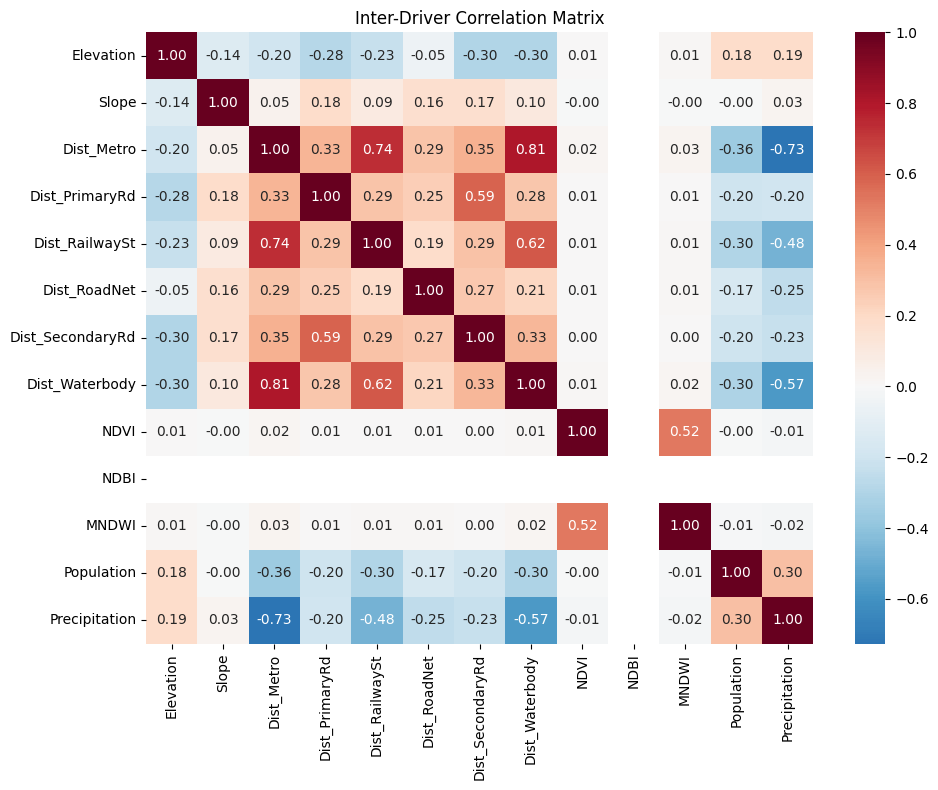

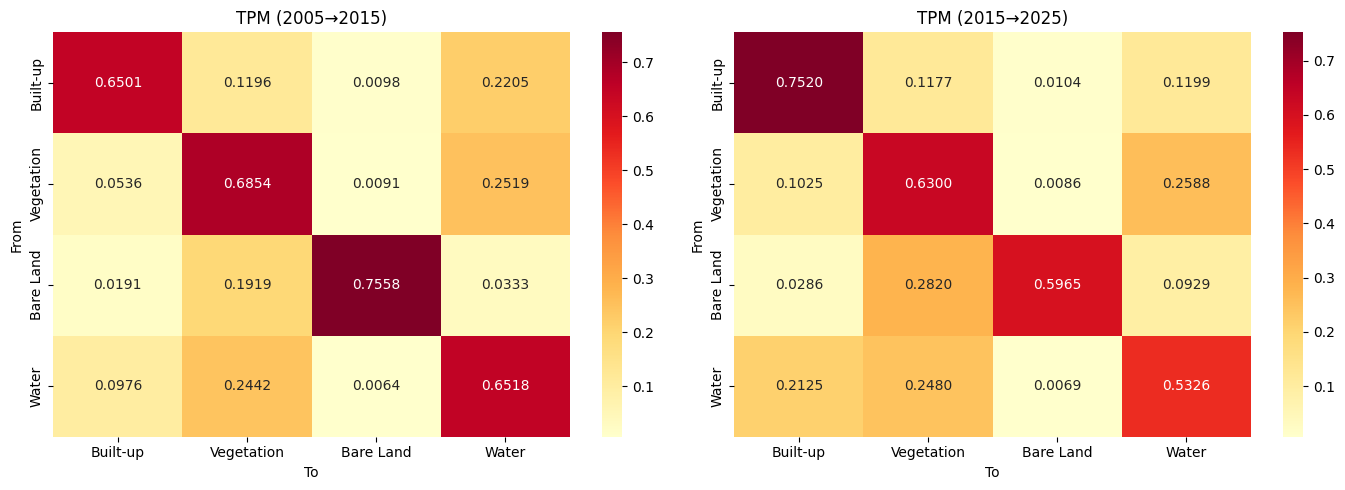


=== LULC Changes 2005–2015 ===
     Class  Px_2005  Px_2015   Delta  DD_%/yr
  Built-up   501258   646342  145084    2.894
Vegetation  1962946  1947682  -15264   -0.078
 Bare Land    24967    55788   30821   12.345
     Water  2201053  2040412 -160641   -0.730

=== LULC Changes 2015–2025 ===
     Class  Px_2015  Px_2025   Delta  DD_%/yr
  Built-up   646342  1120901  474559    7.342
Vegetation  1947682  1824877 -122805   -0.631
 Bare Land    55788    71005   15217    2.728
     Water  2040412  1673441 -366971   -1.799


In [4]:
# --- Pearson Correlation (Paper Sec 3.4.1) ---
def driver_correlations(drv_stack, lulc, mask, names):
    lf = lulc[mask].flatten()
    rows = []
    for i, n in enumerate(names):
        r, p = pearsonr(drv_stack[:,:,i][mask].flatten(), lf)
        rows.append({'Driver': n, 'PCC': round(r,4), '|PCC|': round(abs(r),4)})
    return pd.DataFrame(rows).sort_values('|PCC|', ascending=False)

print("=== Driver–LULC Correlations ===")
print(driver_correlations(driver_norm_2005, lulc_2005, valid_mask, driver_names).to_string(index=False))

# Correlation heatmap
drv_flat = driver_norm_2005[valid_mask].reshape(-1, n_drivers)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(np.corrcoef(drv_flat, rowvar=False), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, xticklabels=driver_names,
            yticklabels=driver_names, ax=ax)
ax.set_title('Inter-Driver Correlation Matrix')
plt.tight_layout()
plt.savefig('/kaggle/working/driver_correlation.png', dpi=150)

plt.show()

# --- Transition Probability Matrix (Markov Chain) ---
def compute_tpm(lulc_from, lulc_to, mask):
    fv, tv = lulc_from[mask].astype(int), lulc_to[mask].astype(int)
    tpm = np.zeros((N_CLASSES, N_CLASSES))
    for i in range(1, N_CLASSES+1):
        for j in range(1, N_CLASSES+1):
            tpm[i-1,j-1] = np.sum((fv==i)&(tv==j))
    rs = tpm.sum(1, keepdims=True); rs[rs==0]=1
    return tpm / rs

tpm_05_15 = compute_tpm(lulc_2005, lulc_2015, valid_mask)
tpm_15_25 = compute_tpm(lulc_2015, lulc_2025, valid_mask)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tpm, t in zip(axes, [tpm_05_15, tpm_15_25], ['2005→2015','2015→2025']):
    sns.heatmap(tpm, annot=True, fmt='.4f', cmap='YlOrRd',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'TPM ({t})'); ax.set_xlabel('To'); ax.set_ylabel('From')
plt.tight_layout()
plt.savefig('/kaggle/working/transition_matrices.png', dpi=150)

plt.show()

# --- LULC Change Analysis ---
def lulc_changes(lf, lt, mask, yf, yt):
    rows = []
    for c in range(1, N_CLASSES+1):
        af = np.sum(lf[mask]==c); at = np.sum(lt[mask]==c)
        dd = ((at-af)/af*100/(yt-yf)) if af>0 else 0
        rows.append({'Class':CLASS_NAMES[c-1], f'Px_{yf}':af, f'Px_{yt}':at,
                     'Delta':at-af, 'DD_%/yr':round(dd,3)})
    return pd.DataFrame(rows)

print("\n=== LULC Changes 2005–2015 ===")
print(lulc_changes(lulc_2005, lulc_2015, valid_mask, 2005, 2015).to_string(index=False))
print("\n=== LULC Changes 2015–2025 ===")
print(lulc_changes(lulc_2015, lulc_2025, valid_mask, 2015, 2025).to_string(index=False))


In [5]:
OUT = '/kaggle/working'

# --- Build feature matrix with all improvements ---
def build_features(lulc_map, drv_now, drv_prev, coords):
    """
    Features: drivers(13) + temporal_deltas(13) + coords(2) 
              + multiscale_proportions(12) + current_class(1) = 41
    """
    drv = drv_now.reshape(-1, drv_now.shape[-1])
    delta = drv - drv_prev.reshape(-1, drv_prev.shape[-1])  # temporal trend
    crd = coords.reshape(-1, 2)
    ms = multiscale_proportions(lulc_map, [3, 7, 15])
    cur = lulc_map.flatten().reshape(-1, 1)
    return np.hstack([drv, delta, crd, ms, cur])

print("Building features...")
# Period 1: 2005→2015 (no prior period, delta=0)
X_p1 = build_features(lulc_2005, driver_norm_2005, driver_norm_2005, coord_stack)
# Period 2: 2015→2025 (delta = 2015 - 2005 captures trend)
X_p2 = build_features(lulc_2015, driver_norm_2015, driver_norm_2005, coord_stack)

vf = valid_mask.flatten()
X_all = np.vstack([X_p1[vf], X_p2[vf]])
y_all = np.concatenate([lulc_2015.flatten()[vf], lulc_2025.flatten()[vf]])

X_tr, y_tr = stratified_sample(X_all, y_all, samples_per_class=100000)
print(f"Training: {len(y_tr):,} samples, {X_all.shape[1]} features")

# --- Train model ---
if HAS_XGB:
    model = XGBClassifier(
        n_estimators=500, max_depth=12, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', n_jobs=-1, random_state=42, verbosity=1
    )
else:
    model = RandomForestClassifier(
        n_estimators=500, max_depth=40, min_samples_leaf=2,
        n_jobs=-1, random_state=42, verbose=1
    )

print(f"\nTraining {'XGBoost' if HAS_XGB else 'Random Forest'}...")

# XGBoost needs 0-indexed classes
if HAS_XGB:
    y_tr = y_tr - 1

model.fit(X_tr, y_tr)

# Remember to add 1 back when predicting later
print("Training complete!")
print("Note: XGBoost classes are 0-indexed, add +1 to predictions")


Building features...
Training: 400,000 samples, 41 features

Training XGBoost...
Training complete!
Note: XGBoost classes are 0-indexed, add +1 to predictions


In [6]:
# --- Predict 2025 from 2015 ---
print("Predicting 2025...")
X_pred = build_features(lulc_2015, driver_norm_2015, driver_norm_2005, coord_stack)
n_px = X_pred.shape[0]
pred_raw = np.zeros(n_px, dtype=int)

BS = 500000
for s in range(0, n_px, BS):
    e = min(s + BS, n_px)
    pred_raw[s:e] = model.predict(X_pred[s:e])
    print(f"  {e:,}/{n_px:,}")

# Add 1 back if XGBoost (0-indexed → 1-indexed)
if HAS_XGB:
    pred_raw = pred_raw + 1

pred_raw_2d = pred_raw.reshape(target_h, target_w)
pred_raw_2d[~valid_mask] = 0

# --- Majority filter (removes salt-and-pepper noise) ---
print("Applying 5x5 majority filter...")
def majority_filter(lulc_map, mask, size=5):
    def local_mode(values):
        vals = values[values > 0]
        if len(vals) == 0: return 0
        return mode(vals, keepdims=False).mode
    filtered = generic_filter(lulc_map.astype(float), local_mode, size=size)
    filtered[~mask] = 0
    return filtered.astype(int)

pred_filtered = majority_filter(pred_raw_2d, valid_mask, size=5)

# --- Accuracy assessment ---
def accuracy_assessment(y_true, y_pred, mask_flat):
    yt = y_true[mask_flat].astype(int)
    yp = y_pred[mask_flat].astype(int)
    oa = accuracy_score(yt, yp)
    kappa = cohen_kappa_score(yt, yp)
    cm = confusion_matrix(yt, yp, labels=[1,2,3,4])
    pa = np.where(cm.sum(0)>0, np.diag(cm)/cm.sum(0)*100, 0)
    ua = np.where(cm.sum(1)>0, np.diag(cm)/cm.sum(1)*100, 0)
    n = cm.sum(); p = cm/n
    q_dis = np.sum(np.abs(p.sum(1)-p.sum(0)))/2
    a_dis = np.sum(np.minimum(p.sum(0)-np.diag(p), p.sum(1)-np.diag(p)))
    print("="*50)
    print(f"Overall Accuracy:         {oa*100:.2f}%")
    print(f"Kappa Coefficient:        {kappa:.4f}")
    print(f"Quantity Disagreement:    {q_dis*100:.2f}%")
    print(f"Allocation Disagreement:  {a_dis*100:.2f}%")
    print(f"\nConfusion Matrix:")
    print(pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES))
    print(f"\nPer-Class Accuracy:")
    print(pd.DataFrame({'Class':CLASS_NAMES,'Producer %':pa.round(2),'User %':ua.round(2)}).to_string(index=False))
    return oa, kappa

print("\n--- RAW prediction ---")
oa_raw, k_raw = accuracy_assessment(lulc_2025.flatten(), pred_raw_2d.flatten(), vf)
print("\n--- After majority filter ---")
oa_filt, k_filt = accuracy_assessment(lulc_2025.flatten(), pred_filtered.flatten(), vf)


Predicting 2025...
  500,000/4,690,224
  1,000,000/4,690,224
  1,500,000/4,690,224
  2,000,000/4,690,224
  2,500,000/4,690,224
  3,000,000/4,690,224
  3,500,000/4,690,224
  4,000,000/4,690,224
  4,500,000/4,690,224
  4,690,224/4,690,224
Applying 5x5 majority filter...

--- RAW prediction ---
Overall Accuracy:         68.55%
Kappa Coefficient:        0.5355
Quantity Disagreement:    6.31%
Allocation Disagreement:  25.14%

Confusion Matrix:
            Built-up  Vegetation  Bare Land    Water
Built-up      906673       63068      11652   139508
Vegetation    173525     1201313      58586   391453
Bare Land        428         383      69886      308
Water         244542      369107      22588  1037204

Per-Class Accuracy:
     Class  Producer %  User %
  Built-up       68.42   80.89
Vegetation       73.53   65.83
 Bare Land       42.95   98.42
     Water       66.13   61.98

--- After majority filter ---
Overall Accuracy:         67.76%
Kappa Coefficient:        0.5235
Quantity Disagreeme

In [7]:
# --- Step 1: Add spectral interaction features ---
def build_features_v7(lulc_map, drv_now, drv_prev, coords):
    drv = drv_now.reshape(-1, drv_now.shape[-1])
    delta = drv - drv_prev.reshape(-1, drv_prev.shape[-1])
    crd = coords.reshape(-1, 2)
    ms = multiscale_proportions(lulc_map, [3, 7, 15])
    cur = lulc_map.flatten().reshape(-1, 1)
    # Spectral interactions: NDVI(idx 10), NDBI(idx 11), MNDWI(idx 12)
    ndvi = drv[:, 10:11]; ndbi = drv[:, 11:12]; mndwi = drv[:, 12:13]
    water_veg_sep = mndwi - ndvi          # high = water
    built_veg_sep = ndbi - ndvi           # high = built-up
    wetness = mndwi + ndvi                # captures wetlands
    return np.hstack([drv, delta, crd, ms, cur, water_veg_sep, built_veg_sep, wetness])

print("Building v7 features...")
X7_p1 = build_features_v7(lulc_2005, driver_norm_2005, driver_norm_2005, coord_stack)
X7_p2 = build_features_v7(lulc_2015, driver_norm_2015, driver_norm_2005, coord_stack)

vf = valid_mask.flatten()
X7_all = np.vstack([X7_p1[vf], X7_p2[vf]])
y7_all = np.concatenate([lulc_2015.flatten()[vf], lulc_2025.flatten()[vf]])

# --- Step 2: Train main 4-class model ---
X7_tr, y7_tr = stratified_sample(X7_all, y7_all, samples_per_class=100000)
if HAS_XGB:
    y7_tr_xgb = y7_tr - 1
    main_model = XGBClassifier(n_estimators=800, max_depth=14, learning_rate=0.08,
                               subsample=0.8, colsample_bytree=0.7,
                               tree_method='hist', n_jobs=-1, random_state=42, verbosity=1)
    main_model.fit(X7_tr, y7_tr_xgb)
else:
    main_model = RandomForestClassifier(n_estimators=600, max_depth=45,
                                        min_samples_leaf=2, n_jobs=-1, random_state=42, verbose=1)
    main_model.fit(X7_tr, y7_tr)

# --- Step 3: Train specialized Water vs Vegetation binary classifier ---
print("\nTraining Water/Vegetation specialist...")
wv_mask = (y7_all == 2) | (y7_all == 4)  # Vegetation=2, Water=4
X_wv = X7_all[wv_mask]
y_wv = y7_all[wv_mask]  # keep original labels

n_wv = min(np.sum(y_wv==2), np.sum(y_wv==4), 150000)
np.random.seed(42)
idx_v = np.random.choice(np.where(y_wv==2)[0], n_wv, replace=False)
idx_w = np.random.choice(np.where(y_wv==4)[0], n_wv, replace=False)
idx_wv = np.concatenate([idx_v, idx_w])
np.random.shuffle(idx_wv)

if HAS_XGB:
    # Map: Veg(2)→0, Water(4)→1
    y_wv_tr = (y_wv[idx_wv] == 4).astype(int)
    wv_model = XGBClassifier(n_estimators=500, max_depth=10, learning_rate=0.1,
                             subsample=0.8, tree_method='hist', n_jobs=-1, random_state=42)
    wv_model.fit(X_wv[idx_wv], y_wv_tr)
else:
    y_wv_tr = y_wv[idx_wv]
    wv_model = RandomForestClassifier(n_estimators=400, max_depth=30,
                                       n_jobs=-1, random_state=42)
    wv_model.fit(X_wv[idx_wv], y_wv_tr)

print(f"Water/Veg specialist trained on {len(idx_wv):,} samples")

# --- Step 4: Predict with hierarchical approach ---
print("\nPredicting 2025 (hierarchical)...")
X7_pred = build_features_v7(lulc_2015, driver_norm_2015, driver_norm_2005, coord_stack)

# Main model prediction
pred_main = np.zeros(n_px, dtype=int)
BS = 500000
for s in range(0, n_px, BS):
    e = min(s + BS, n_px)
    pred_main[s:e] = main_model.predict(X7_pred[s:e])
if HAS_XGB:
    pred_main = pred_main + 1

# Override Water/Veg predictions with specialist
wv_pixels = ((pred_main == 2) | (pred_main == 4)) & vf
wv_indices = np.where(wv_pixels)[0]
print(f"Re-classifying {len(wv_indices):,} Water/Veg pixels with specialist...")

for s in range(0, len(wv_indices), BS):
    e = min(s + BS, len(wv_indices))
    batch_idx = wv_indices[s:e]
    wv_pred = wv_model.predict(X7_pred[batch_idx])
    if HAS_XGB:
        pred_main[batch_idx] = np.where(wv_pred == 1, 4, 2)  # 1=Water, 0=Veg
    else:
        pred_main[batch_idx] = wv_pred

pred_v7 = pred_main.reshape(target_h, target_w)
pred_v7[~valid_mask] = 0

print("\n--- Hierarchical model ---")
oa7, k7 = accuracy_assessment(lulc_2025.flatten(), pred_v7.flatten(), vf)
print(f"\nPrevious best: OA=68.55%, K=0.536 → Now: OA={oa7*100:.2f}%, K={k7:.4f}")


Building v7 features...

Training Water/Vegetation specialist...
Water/Veg specialist trained on 300,000 samples

Predicting 2025 (hierarchical)...
Re-classifying 3,206,790 Water/Veg pixels with specialist...

--- Hierarchical model ---
Overall Accuracy:         68.72%
Kappa Coefficient:        0.5379
Quantity Disagreement:    6.22%
Allocation Disagreement:  25.06%

Confusion Matrix:
            Built-up  Vegetation  Bare Land    Water
Built-up      910523       62643      11228   136507
Vegetation    169705     1207299      57869   390004
Bare Land        423         327      70004      251
Water         241718      374305      21964  1035454

Per-Class Accuracy:
     Class  Producer %  User %
  Built-up       68.86   81.23
Vegetation       73.41   66.16
 Bare Land       43.46   98.59
     Water       66.28   61.88

Previous best: OA=68.55%, K=0.536 → Now: OA=68.72%, K=0.5379


--- Projecting 2035 LULC ---
--- Projecting 2045 LULC ---
Saved: /kaggle/working/projected_2035.tif
Saved: /kaggle/working/projected_2045.tif

COMPREHENSIVE LULC AREA ANALYSIS (Pixels & Sq Km)


,Year,Built-up (px),Built-up (km²),Vegetation (px),Vegetation (km²),Bare Land (px),Bare Land (km²),Water (px),Water (km²),Metric
0,2005 (Actual),501258,451.132200,1962946,1766.651400,24967,22.470300,2201053,1980.947700,nan
1,2015 (Actual),646342,581.707800,1947682,1752.913800,55788,50.209200,2040412,1836.370800,nan
2,2025 (Actual),1120901,1008.810900,1824877,1642.389300,71005,63.904500,1673441,1506.096900,nan
3,2035 (Predicted),1405892,1265.302800,1604395,1443.955500,226734,204.060600,1453203,1307.882700,nan
4,2045 (Predicted),1514929,1363.436100,1507896,1357.106400,406950,366.255000,1260449,1134.404100,nan
5,nan,-,+912.30 (+202.2%),-,-409.55 (-23.2%),-,+343.78 (+1530.0%),-,-846.54 (-42.7%),Net Change (2005→2045)


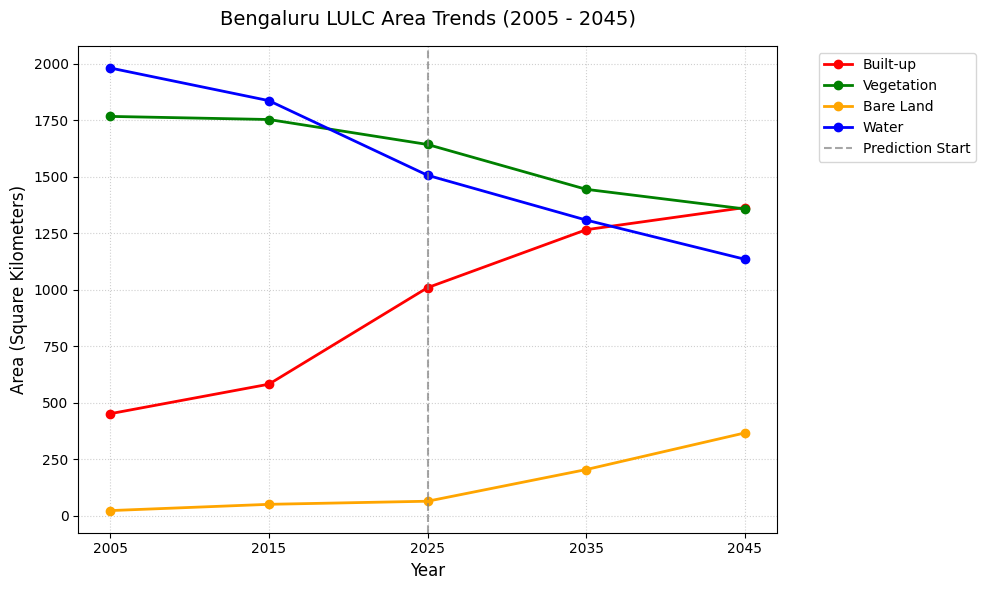

Saved trend chart: /kaggle/working/lulc_area_trends.png


In [8]:
# =====================================================================
# STAGE 8: FUTURE LULC PROJECTION (2035 & 2045) & CHANGE ANALYSIS
# =====================================================================
import os
from IPython.display import display

print("--- Projecting 2035 LULC ---")
# To predict 2035, we use the actual 2025 LULC map + 2015 static/temporal drivers
X_pred_35 = build_features(lulc_2025, driver_norm_2015, driver_norm_2015, coord_stack)

pred_35_raw = np.zeros(n_px, dtype=int)
for s in range(0, n_px, BS):
    e = min(s + BS, n_px)
    pred_35_raw[s:e] = model.predict(X_pred_35[s:e])

# 0-indexed to 1-indexed for XGBoost
if HAS_XGB:
    pred_35_raw = pred_35_raw + 1

pred_35_2d = pred_35_raw.reshape(target_h, target_w)
pred_35_2d[~valid_mask] = 0

print("--- Projecting 2045 LULC ---")
# To predict 2045, we use the simulated 2035 LULC map + 2015 static/temporal drivers
X_pred_45 = build_features(pred_35_2d, driver_norm_2015, driver_norm_2015, coord_stack)

pred_45_raw = np.zeros(n_px, dtype=int)
for s in range(0, n_px, BS):
    e = min(s + BS, n_px)
    pred_45_raw[s:e] = model.predict(X_pred_45[s:e])

if HAS_XGB:
    pred_45_raw = pred_45_raw + 1

pred_45_2d = pred_45_raw.reshape(target_h, target_w)
pred_45_2d[~valid_mask] = 0

# --- Save Projected Rasters ---
def save_raster(data, reference_meta, path):
    meta = reference_meta.copy()
    meta.update(dtype='float32', count=1, height=data.shape[0], width=data.shape[1])
    with rasterio.open(path, 'w', **meta) as dst:
        dst.write(data.astype(np.float32), 1)
    print(f"Saved: {path}")

os.makedirs(OUT, exist_ok=True)
save_raster(pred_35_2d, meta_2015, f'{OUT}/projected_2035.tif')
save_raster(pred_45_2d, meta_2015, f'{OUT}/projected_2045.tif')

# =====================================================================
# STATISTICAL ANALYSIS: LULC AREA CHANGES (2005 to 2045)
# =====================================================================
print("\n" + "="*50)
print("COMPREHENSIVE LULC AREA ANALYSIS (Pixels & Sq Km)")
print("="*50)

# 1 pixel = 30m x 30m = 900 sq meters = 0.0009 sq km
PIXEL_TO_SQKM = 0.0009 

maps_timeline = {
    '2005 (Actual)': lulc_2005,
    '2015 (Actual)': lulc_2015,
    '2025 (Actual)': lulc_2025,
    '2035 (Predicted)': pred_35_2d,
    '2045 (Predicted)': pred_45_2d
}

stats = []
for year, arr in maps_timeline.items():
    row = {'Year': year}
    for c_idx, c_name in enumerate(CLASS_NAMES, start=1):
        px_count = np.sum(arr[valid_mask] == c_idx)
        row[f'{c_name} (px)'] = px_count
        row[f'{c_name} (km²)'] = px_count * PIXEL_TO_SQKM
    stats.append(row)

df_stats = pd.DataFrame(stats)

# Calculate percentage changes (2005 to 2045)
net_changes = {'Metric': 'Net Change (2005→2045)'}
for c_name in CLASS_NAMES:
    area_2005 = df_stats.loc[0, f'{c_name} (km²)']
    area_2045 = df_stats.loc[4, f'{c_name} (km²)']
    diff_sqkm = area_2045 - area_2005
    pct_change = (diff_sqkm / area_2005) * 100 if area_2005 > 0 else 0
    net_changes[f'{c_name} (px)'] = "-"
    net_changes[f'{c_name} (km²)'] = f"{diff_sqkm:+.2f} ({pct_change:+.1f}%)"

df_stats = pd.concat([df_stats, pd.DataFrame([net_changes])], ignore_index=True)

# Formatting for nice display
float_cols = [col for col in df_stats.columns if '(km²)' in col and df_stats[col].dtype == float]
display(df_stats.style.format({c: "{:.2f}" for c in float_cols}))

# =====================================================================
# VISUALIZATION: AREA TRENDS
# =====================================================================
years_num = [2005, 2015, 2025, 2035, 2045]
colors = ['red', 'green', 'orange', 'blue'] # Built-up, Veg, Bare, Water

plt.figure(figsize=(10, 6))
for i, c_name in enumerate(CLASS_NAMES):
    areas = [df_stats.loc[j, f'{c_name} (km²)'] for j in range(5)]
    plt.plot(years_num, areas, marker='o', linewidth=2, color=colors[i], label=c_name)

plt.axvline(x=2025, color='gray', linestyle='--', alpha=0.7, label='Prediction Start')
plt.title('Bengaluru LULC Area Trends (2005 - 2045)', fontsize=14, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Area (Square Kilometers)', fontsize=12)
plt.xticks(years_num)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{OUT}/lulc_area_trends.png', dpi=150)
plt.show()
print(f"Saved trend chart: {OUT}/lulc_area_trends.png")
